<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>



# Laboratorium nr 11: Autoencoders

## Import bibliotek

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)

2026-04-15 11:00:55.167673: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 11:00:55.206061: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-15 11:00:57.292811: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Numpy version: 2.4.2
Tensorflow version: 2.20.0


## Baza MNIST

- Baza MNIST zawiera zbiór trenujący składający się z 60,000 przykładów skanów ręcznie pisanych cyfr od 0 do 9 (problem klasyfikacyjny z 10 klasami).
- Zbiór testowy zawiera 10,000 przykładów.
- Każdy obraz ma rozmiar 28x28 pikseli. Stanowią one 28 * 28 = 784 wejść do sieci.

#### Pobieranie bazy MNIST
- Bazę MNIST można pobrać bespośrednio ze strony http://yann.lecun.com/exdb/mnist/
- Najwygodniej jednak jest użyć bazy MNIST z wykorzystaniem biblioteki Keras

In [ ]:
(train_images, train_labels), (test_images, test_labels) = (
    tf.keras.datasets.mnist.load_data()
)
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)
train_images = np.expand_dims(train_images, axis=-1) / 255.0
train_labels = np.int64(train_labels)
test_images = np.expand_dims(test_images, axis=-1) / 255.0
test_labels = np.int64(test_labels)
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
(60000, 28, 28, 1) (60000,) (10000, 28, 28, 1) (10000,)


Przykładowe cyfry:

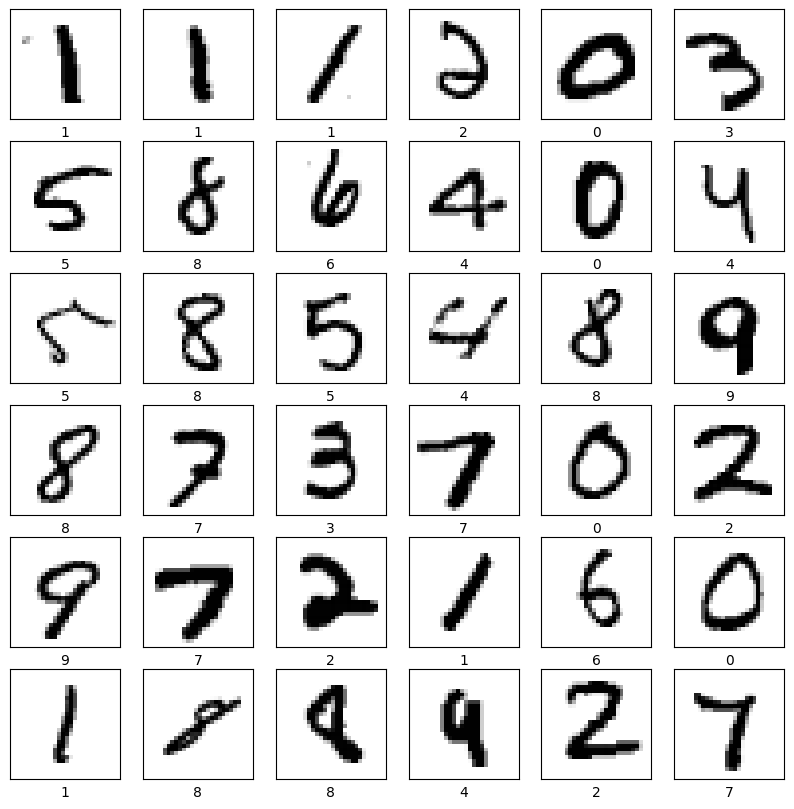

In [ ]:
plt.figure(figsize=(10, 10))
random_inds = np.random.choice(60000, 36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    plt.imshow(np.squeeze(train_images[image_ind]), cmap=plt.cm.binary)
    plt.xlabel(train_labels[image_ind])

# AutoEncoder
Stwórz model AutoEncodera. Użyj warst Dense. Wytrenuj i zwizualizuj odtworzone cyfry.

In [ ]:
from keras.layers import (
    Input,
    Dense,
    Flatten,
    Conv2D,
    MaxPool2D,
    Dropout,
    Conv2DTranspose,
    Reshape,
)
from keras.models import Model, Sequential


def encoder(n):
    x = Input(shape=(28, 28, 1))
    xf = Flatten()(x)
    y = Dense(128, activation="relu")(xf)
    y = Dense(128, activation="relu")(y)
    y = Dense(n, activation="tanh")(y)
    return Model(inputs=x, outputs=y)


def decoder(n):
    x = Input(shape=(n,))

    y = Dense(128, activation="relu")(x)
    y = Dense(128, activation="relu")(x)
    y = Dense(28 * 28, activation="relu")(y)
    y = Reshape((28, 28, 1))(y)
    return Model(inputs=x, outputs=y)

In [ ]:
def encoder(n):
    x = Input(shape=(28, 28, 1))
    xf = Flatten()(x)
    y = Dense(128, activation="relu")(xf)
    y = Dense(128, activation="relu")(y)
    y = Dense(n, activation="tanh")(y)
    return Model(inputs=x, outputs=y)


def decoder(n):
    x = Input(shape=(n,))

    y = Dense(128, activation="relu")(x)
    y = Dense(128, activation="relu")(x)
    y = Dense(28 * 28, activation="relu")(y)
    y = Reshape((28, 28, 1))(y)

    yp = Dense(128, activation="relu")(x)
    yp = Dense(128, activation="relu")(yp)
    yp = Dense(10, activation="softmax")(yp)
    return Model(inputs=x, outputs=[y, yp])

IOStream.flush timed out


In [6]:
# model autoencodera i trenowanie
n = 2
enc: Model = encoder(n)
dec: Model = decoder(n)
ae_model: Sequential = Sequential([enc, dec])
ae_model.summary()

I0000 00:00:1776243660.082534  127701 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9558 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:02:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 2)              │       117,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ [(None, 28, 28, 1),    │       119,706 │
│                                 │ (None, 10)]            │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,956 (925.61 KB)

 Trainable params: 236,956 (925.61 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
dec.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │        384 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │        384 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 784)       │    101,136 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     16,512 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │      1,290 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 119,706 (467.60 KB)

 Trainable params: 119,706 (467.60 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ae_model.compile(
    optimizer="adam",
    loss=["mse", "sparse_categorical_crossentropy"],
    metrics=["mse", "accuracy"],
)
# ae_model.compile(optimizer='adam', loss=['mse'])
ae_model.fit(
    train_images,
    [train_images, train_labels],
    epochs=30,
    batch_size=128,
    validation_split=0.1,
)
# ae_model.fit(train_images, train_images, epochs=30, batch_size=128, validation_split=0.1)

Epoch 1/30


2026-04-15 11:01:02.438462: I external/local_xla/xla/service/service.cc:163] XLA service 0x7271d8002840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-15 11:01:02.438493: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2026-04-15 11:01:02.464705: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-15 11:01:02.669366: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-04-15 11:01:02.692341: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-15 11:01:02.692458: I e

 60/422 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2562 - loss: 2.1522 - mse: 0.0937 - mse_loss: 0.0937 - sparse_categorical_crossentropy_loss: 2.0585

I0000 00:00:1776243665.405831  127817 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


405/422 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5349 - loss: 1.3406 - mse: 0.0715 - mse_loss: 0.0715 - sparse_categorical_crossentropy_loss: 1.2690

2026-04-15 11:01:06.683070: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-15 11:01:06.683190: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-15 11:01:06.683265: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-15 11:01:06.814792: I external/l

422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7194 - loss: 0.8682 - mse: 0.0634 - mse_loss: 0.0634 - sparse_categorical_crossentropy_loss: 0.8047 - val_accuracy: 0.9058 - val_loss: 0.4110 - val_mse: 0.0583 - val_mse_loss: 0.0583 - val_sparse_categorical_crossentropy_loss: 0.3529
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9236 - loss: 0.3436 - mse: 0.0581 - mse_loss: 0.0581 - sparse_categorical_crossentropy_loss: 0.2855 - val_accuracy: 0.9468 - val_loss: 0.2634 - val_mse: 0.0565 - val_mse_loss: 0.0565 - val_sparse_categorical_crossentropy_loss: 0.2070
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9493 - loss: 0.2452 - mse: 0.0570 - mse_loss: 0.0570 - sparse_categorical_crossentropy_loss: 0.1882 - val_accuracy: 0.9557 - val_loss: 0.2273 - val_mse: 0.0554 - val_mse_loss: 0.0554 - val_sparse_categorical_crossentropy_loss: 0.1719
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9610 - loss: 0.2021 - mse: 0.0560 - mse_loss

In [9]:
# predykcja
imgs = train_images[:10]
# pred = ae_model.predict(imgs)
pred = ae_model.predict(imgs)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step


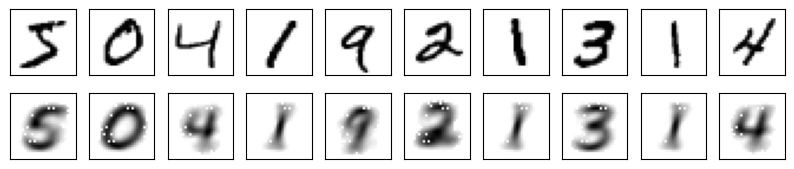

In [ ]:
# wizualizacja
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(imgs[i]), cmap=plt.cm.binary)
    plt.subplot(2, 10, i + 1 + 10)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(pred[i]), cmap=plt.cm.binary)
    # plt.xlabel(train_labels[image_ind])

In [ ]:
# losowe wektory
ran = np.random.random((10, n)) * 2 - 1
ran

array([[-0.73621343, -0.49467323],
       [ 0.01496075,  0.23126387],
       [-0.44045953, -0.00806108],
       [-0.30452794,  0.83901263],
       [ 0.32471985,  0.02678351],
       [-0.54468999, -0.01639206],
       [-0.30537917, -0.7654568 ],
       [-0.49988171,  0.68255667],
       [-0.15947951, -0.87055099],
       [ 0.06192686, -0.38604152]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step


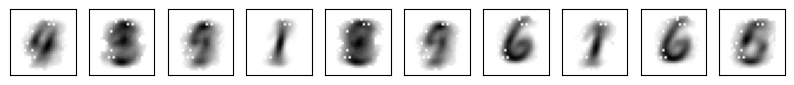

In [ ]:
ran_imgs = dec.predict(ran)[0]
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(ran_imgs[i]), cmap=plt.cm.binary)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


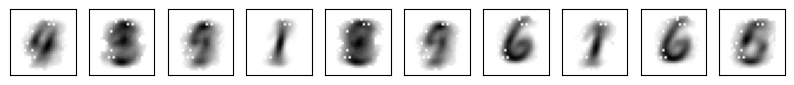

In [ ]:
ran_imgs = dec.predict(ran)[0]
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(ran_imgs[i]), cmap=plt.cm.binary)

## Wizualizacje przestrzeni ukrytej

In [14]:
latent = enc.predict(train_images)

2026-04-15 11:01:58.526135: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-15 11:01:58.723679: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24', 20 bytes spill stores, 20 bytes spill loads

2026-04-15 11:01:58.809619: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_17', 100 bytes spill stores, 100 bytes spill loads

2026-04-15 11:01:58.874103: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_17', 48 bytes 

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 714us/step


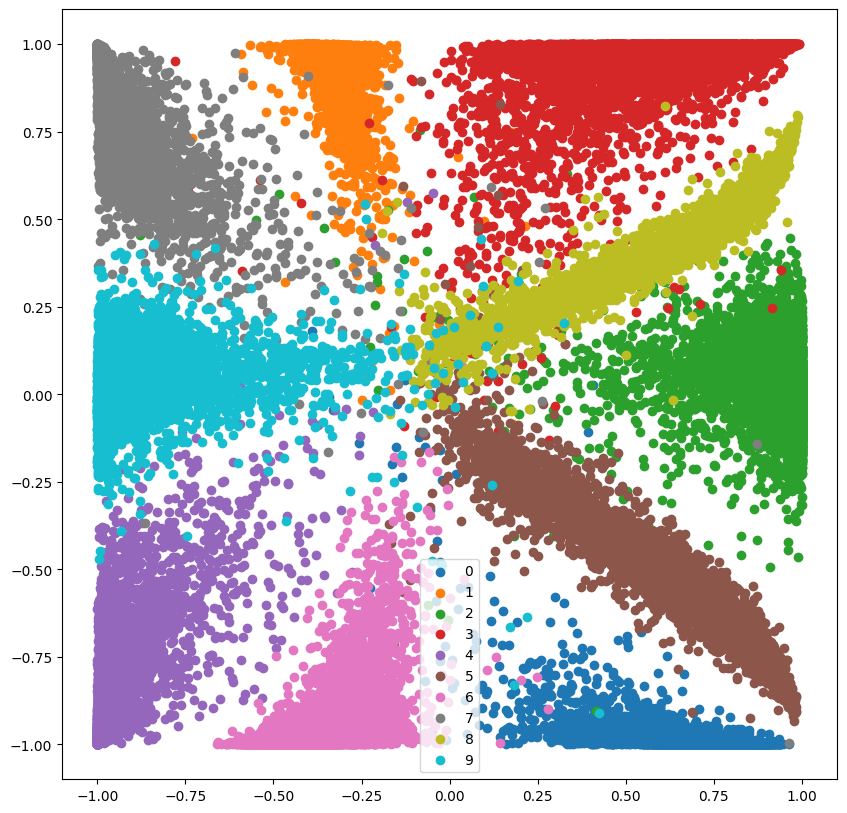

In [ ]:
# wizualizacja
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.scatter(
        latent[np.where(train_labels == i), 0],
        latent[np.where(train_labels == i), 1],
        label=str(i),
    )
plt.legend()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


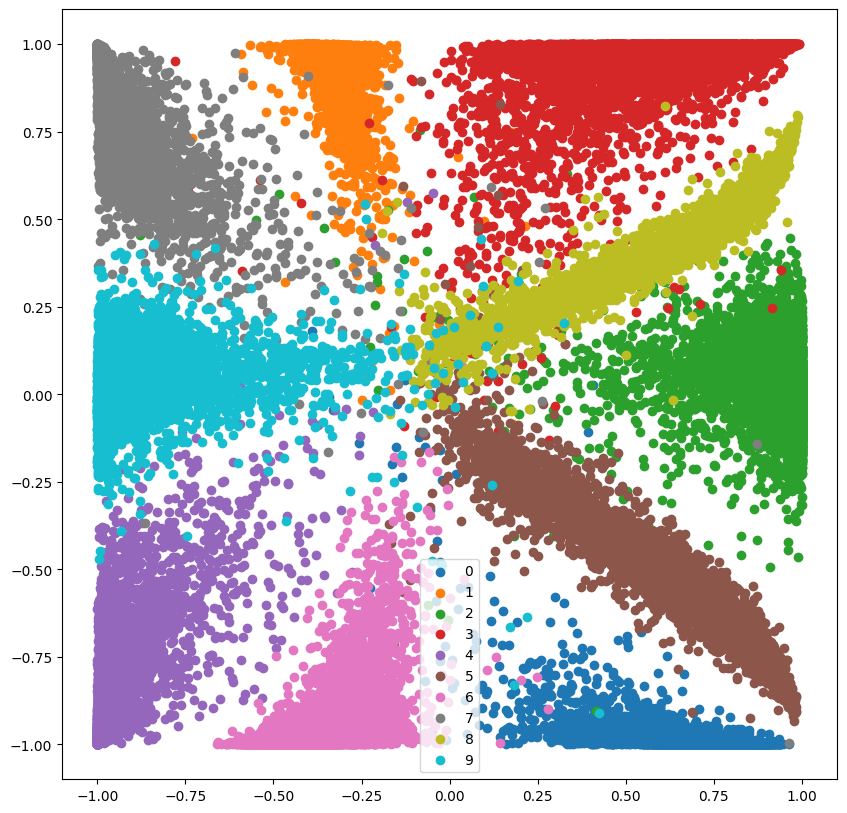

In [ ]:
latent2 = enc.predict(train_images)
# wizualizacja
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.scatter(
        latent2[np.where(train_labels == i), 0],
        latent2[np.where(train_labels == i), 1],
        label=str(i),
    )
plt.legend()

In [17]:
preed = ae_model.predict(train_images)

2026-04-15 11:02:04.936030: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_85', 20 bytes spill stores, 20 bytes spill loads



1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 962us/step


In [ ]:
er = np.mean((preed[0] - train_images) ** 2, axis=(1, 2, 3))
er

array([0.05964981, 0.03881549, 0.06336254, ..., 0.04695942, 0.05501514,
       0.05839441], shape=(60000,))

0


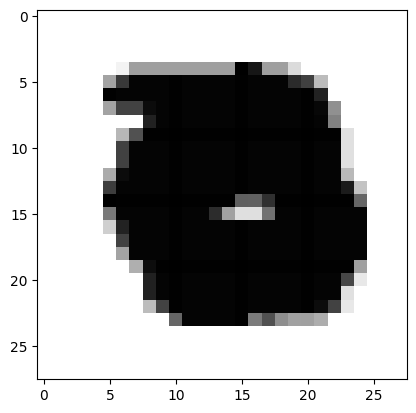

In [19]:
idx = np.argmax(er)
plt.imshow(np.squeeze(train_images[idx]), cmap=plt.cm.binary)
print(train_labels[idx])

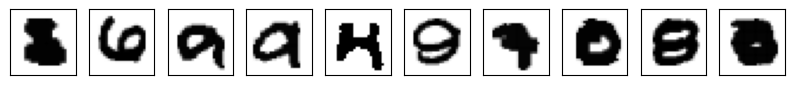

In [ ]:
idxs = np.argsort(er)[-10:]
ran_imgs = train_images[idxs]
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(ran_imgs[i]), cmap=plt.cm.binary)

## Ćwiczenia do wykonania
- Dodaj do modelu klasyfikator, tak aby encoder uczył się reprezentacji ułatwiającej rozwiązanie problemu klasyfikacji, zwizualizuj przestrzeń ukrytą
- Dokonaj redukcji wymiarowości innymi algorytmami np. PCA, i zwizualizuj
- Zdefiniuj enkoder i dekoder używając warst odpowiednio konwolucyjnych i dekonwolucyjnych. Porównaj wyniki.

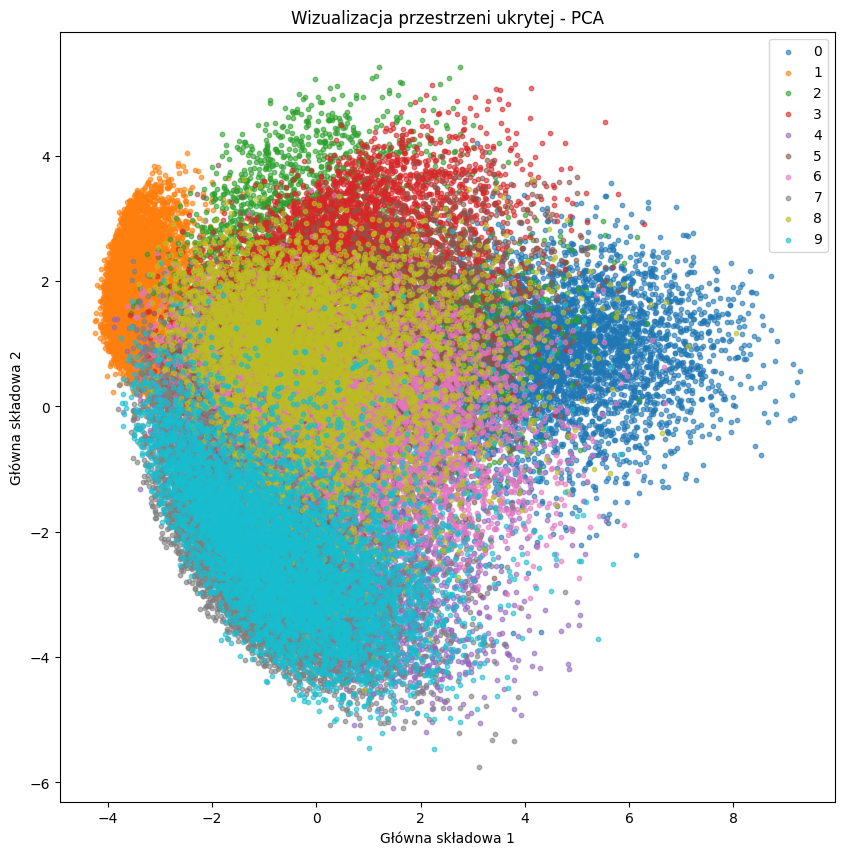

In [ ]:
from sklearn.decomposition import PCA

# Spłaszczenie obrazów do postaci wektorów (60000, 784)
X_flat = train_images.reshape(train_images.shape[0], -1)

# Redukcja wymiarowości za pomocą PCA do 2 wymiarów
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(X_flat)

# Wizualizacja
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.scatter(
        latent_pca[np.where(train_labels == i), 0],
        latent_pca[np.where(train_labels == i), 1],
        label=str(i),
        alpha=0.6,
        s=10,
    )
plt.legend()
plt.title("Wizualizacja przestrzeni ukrytej - PCA")
plt.xlabel("Główna składowa 1")
plt.ylabel("Główna składowa 2")
plt.show()

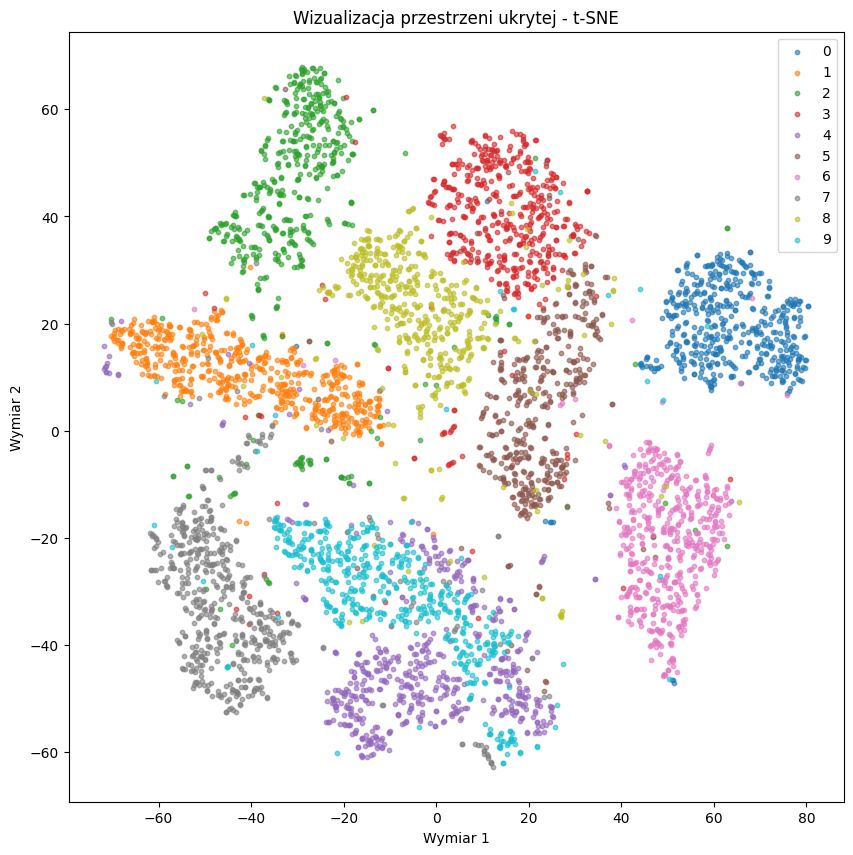

In [ ]:
from sklearn.manifold import TSNE

subset_size = 5000
X_subset = X_flat[:subset_size]
labels_subset = train_labels[:subset_size]

# Redukcja wymiarowości za pomocą t-SNE do 2 wymiarów
tsne = TSNE(n_components=2, random_state=42)
latent_tsne = tsne.fit_transform(X_subset)

# Wizualizacja
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.scatter(
        latent_tsne[np.where(labels_subset == i), 0],
        latent_tsne[np.where(labels_subset == i), 1],
        label=str(i),
        alpha=0.6,
        s=10,
    )
plt.legend()
plt.title("Wizualizacja przestrzeni ukrytej - t-SNE")
plt.xlabel("Wymiar 1")
plt.ylabel("Wymiar 2")
plt.show()

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.2573 - val_loss: 0.2154
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2068 - val_loss: 0.2001
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1970 - val_loss: 0.1938
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1919 - val_loss: 0.1901
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1890 - val_loss: 0.1868
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1865 - val_loss: 0.1852
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1846 - val_loss: 0.1836
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1830 - val_loss: 0.1824
Epoch 9/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1816 - val_loss: 0.1806
Epoch 10/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1806 - val_loss: 0.1798
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step


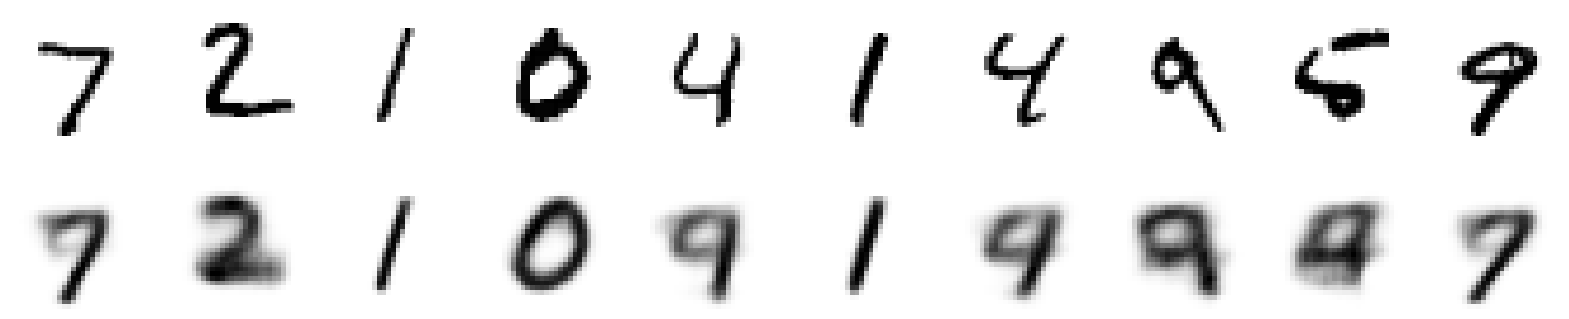

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


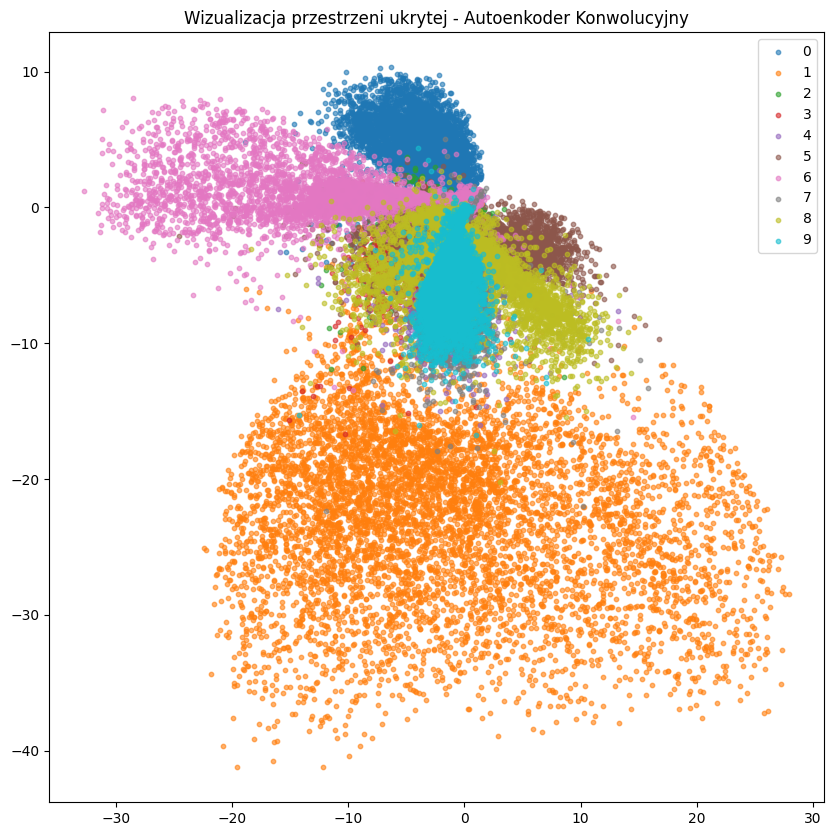

In [ ]:
def encoder_conv(n):
    inputs = Input(shape=(28, 28, 1))
    x = Conv2D(32, (3, 3), activation="relu", padding="same", strides=2)(inputs)
    x = Conv2D(64, (3, 3), activation="relu", padding="same", strides=2)(x)
    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)
    latent = Dense(n, activation="linear")(x)
    return Model(inputs, latent, name="encoder_conv")


def decoder_conv(n):
    latent_inputs = Input(shape=(n,))
    x = Dense(7 * 7 * 64, activation="relu")(latent_inputs)
    x = Reshape((7, 7, 64))(x)
    x = Conv2DTranspose(64, (3, 3), activation="relu", padding="same", strides=2)(x)
    x = Conv2DTranspose(32, (3, 3), activation="relu", padding="same", strides=2)(x)
    outputs = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)
    return Model(latent_inputs, outputs, name="decoder_conv")


# Parametry
latent_dim_conv = 2

# Inicjalizacja modeli
enc_conv = encoder_conv(latent_dim_conv)
dec_conv = decoder_conv(latent_dim_conv)

# Połączenie w Autoenkoder
inputs_conv = Input(shape=(28, 28, 1))
latent_conv = enc_conv(inputs_conv)
outputs_conv = dec_conv(latent_conv)
ae_conv = Model(inputs_conv, outputs_conv, name="autoencoder_conv")

# Kompilacja i trenowanie
ae_conv.compile(optimizer="adam", loss="binary_crossentropy")
ae_conv.fit(train_images, train_images, epochs=10, batch_size=128, validation_split=0.1)

# Przewidywanie i wizualizacja
pred_conv = ae_conv.predict(test_images[:10])

plt.figure(figsize=(20, 4))
for i in range(10):
    # Oryginał
    plt.subplot(2, 10, i + 1)
    plt.imshow(np.squeeze(test_images[i]), cmap="binary")
    plt.axis("off")

    # Rekonstrukcja
    plt.subplot(2, 10, i + 11)
    plt.imshow(np.squeeze(pred_conv[i]), cmap="binary")
    plt.axis("off")
plt.show()

# Wizualizacja przestrzeni ukrytej
latent_conv_vals = enc_conv.predict(train_images)

plt.figure(figsize=(10, 10))
for i in range(10):
    plt.scatter(
        latent_conv_vals[np.where(train_labels == i), 0],
        latent_conv_vals[np.where(train_labels == i), 1],
        label=str(i),
        alpha=0.6,
        s=10,
    )
plt.legend()
plt.title("Wizualizacja przestrzeni ukrytej - Autoenkoder Konwolucyjny")
plt.show()

# VAE - Debiasing Facial Detection Systems - MIT Deep Learning

In [ ]:
import pdb
import cv2
import os
import time
import h5py
import sys

IM_SHAPE = (64, 64, 3)


class TrainingDatasetLoader(object):
    def __init__(self, data_path):
        print("Opening {}".format(data_path))
        sys.stdout.flush()
        self.cache = h5py.File(data_path, "r")
        print("Loading data into memory...")
        sys.stdout.flush()
        self.images = self.cache["images"][:]
        self.labels = self.cache["labels"][:]
        self.image_dims = self.images.shape
        n_train_samples = self.image_dims[0]
        self.train_inds = np.random.permutation(np.arange(n_train_samples))
        self.pos_train_inds = self.train_inds[self.labels[self.train_inds, 0] == 1.0]
        self.neg_train_inds = self.train_inds[self.labels[self.train_inds, 0] != 1.0]

    def get_train_size(self):
        return self.train_inds.shape[0]

    def get_train_steps_per_epoch(self, batch_size, factor=10):
        return self.get_train_size() // factor // batch_size

    def get_batch(self, n, only_faces=False, p_pos=None, p_neg=None, return_inds=False):
        if only_faces:
            selected_inds = np.random.choice(
                self.pos_train_inds, size=n, replace=False, p=p_pos
            )
        else:
            selected_pos_inds = np.random.choice(
                self.pos_train_inds, size=n // 2, replace=False, p=p_pos
            )
            selected_neg_inds = np.random.choice(
                self.neg_train_inds, size=n // 2, replace=False, p=p_neg
            )
            selected_inds = np.concatenate((selected_pos_inds, selected_neg_inds))
        sorted_inds = np.sort(selected_inds)
        train_img = self.images[sorted_inds, :, :, ::-1] / 255.0
        train_label = self.labels[sorted_inds, ...]
        return (
            (train_img, train_label, sorted_inds)
            if return_inds
            else (train_img, train_label)
        )

    def get_n_most_prob_faces(self, prob, n):
        idx = np.argsort(prob)[::-1]
        most_prob_inds = self.pos_train_inds[idx[: 10 * n : 10]]
        return self.images[most_prob_inds, ...] / 255.0

    def get_all_train_faces(self):
        return self.images[self.pos_train_inds]


class PPBFaceEvaluator:
    """Evaluate on the PPB dataset"""

    def __init__(self, skip=4):
        path_to_faces = tf.keras.utils.get_file(
            "ppb",
            "https://www.dropbox.com/s/l0lp6qxeplumouf/PPB.tar?dl=1",
            extract=True,
        )
        self.ppb_root = os.path.join(os.path.split(path_to_faces)[0], "ppb/PPB-2017")
        ppb_anno = os.path.join(self.ppb_root, "PPB-2017-metadata.csv")
        self.anno_dict = {}
        with open(ppb_anno) as f:
            for line in f.read().split("\n"):
                ind, name, gender, numeric, skin, country = line.split(",")
                self.anno_dict[name] = (gender.lower(), skin.lower())

        image_dir = os.path.join(self.ppb_root, "imgs")
        image_files = sorted(os.listdir(image_dir))[
            ::skip
        ]  # sample every 4 images for computation time in the lab
        self.raw_images = {
            "male_darker": [],
            "male_lighter": [],
            "female_darker": [],
            "female_lighter": [],
        }
        for filename in image_files:
            if not filename.endswith(".jpg"):
                continue
            image = cv2.imread(os.path.join(image_dir, filename))[:, :, ::-1]
            gender, skin = self.anno_dict[filename]
            self.raw_images[gender + "_" + skin].append(image)

    def get_sample_faces_from_demographic(self, gender, skin_color):
        key = self.__get_key(gender, skin_color)
        data = self.raw_images[key][50] / 255.0
        return data

    def evaluate(
        self,
        models_to_test,
        gender,
        skin_color,
        output_idx=None,
        from_logit=False,
        patch_stride=0.2,
        patch_depth=5,
    ):
        correct_predictions = [0.0] * len(models_to_test)
        key = self.__get_key(gender, skin_color)
        num_faces = len(self.raw_images[key])
        for face_idx in range(num_faces):
            image = self.raw_images[key][face_idx]
            height, width, _ = image.shape
            patches, bboxes = slide_square(
                image, patch_stride, width / 2, width, patch_depth
            )
            patches = np.array(patches) / 255.0
            for model_idx, model in enumerate(models_to_test):
                out = model.predict(patches, verbose=0)
                y = out if output_idx is None else out[output_idx]
                y_inds = np.argmax(y, axis=1)
                # most_likely_prob = y[y_inds[-1]]
                # if y_inds == 1:
                correct_predictions[model_idx] += np.mean(np.abs(1 - y_inds))
        accuracy = [
            correct_predictions[i] / num_faces for i, _ in enumerate(models_to_test)
        ]
        return accuracy

    def __get_key(self, gender, skin_color):
        gender = gender.lower()
        skin_color = skin_color.lower()
        assert gender in ["male", "female"]
        assert skin_color in ["lighter", "darker"]
        return "{}_{}".format(gender, skin_color)


""" function to slide a square across image and extract square regions
img = the image
stride = (0,1], provides the fraction of the dimension for which to slide to generate a crop
max_size = maximum square size
min_size = minimum square size
n = number of different sizes including min_size, max_size """


def slide_square(img, stride, min_size, max_size, n):
    img_h, img_w = img.shape[:2]
    square_sizes = np.linspace(min_size, max_size, n, dtype=np.int32)
    square_images = []
    square_bbox = (
        []
    )  # list of list of tuples: [(i1,j1), (i2,j2)] where i1,j1 is the top left corner; i2,j2 is bottom right corner
    # for each of the square_sizes
    for level, sq_dim in enumerate(square_sizes):
        stride_length = int(stride * sq_dim)
        stride_start_i = range(0, int(img_h - sq_dim + 1), stride_length)
        stride_start_j = range(0, int(img_w - sq_dim + 1), stride_length)
        for i in stride_start_i:
            for j in stride_start_j:
                square_top_left = (i, j)
                square_bottom_right = (i + sq_dim, j + sq_dim)
                square_corners = (square_top_left, square_bottom_right)
                square_corners_show = ((j, i), (j + sq_dim, i + sq_dim))
                square_image = img[i : i + sq_dim, j : j + sq_dim]
                square_resize = cv2.resize(
                    square_image, IM_SHAPE[:2], interpolation=cv2.INTER_NEAREST
                )
                # append to list of images and bounding boxes
                square_images.append(square_resize)
                square_bbox.append(square_corners)
    return square_images, square_bbox

### Datasets
1. __Positive training data__: CelebA Dataset. A large-scale (over 200K images) of celebrity faces.
2. __Negative training data__: ImageNet. Many images across many different categories. We'll take negative examples from a variety of non-human categories.
3. __Test data__: Pilot Parliaments Benchmark (PPB). The PPB dataset consists of images of 1270 male and female parliamentarians from various African and European countries and exhibits parity in both skin tone and gender. The gender of each face is annotated with the sex-based "Male'' and "Female'' labels. Skin tone annotations are based on the Fitzpatrick skin type classification system, with each image labeled as "Lighter'' or "Darker''.

In [ ]:
# Get the training data: both images from CelebA and ImageNet
path_to_training_data = keras.utils.get_file(
    "train_face.h5", "https://www.dropbox.com/s/l5iqduhe0gwxumq/train_face.h5?dl=1"
)
# Instantiate a TrainingDatasetLoader using the downloaded dataset
loader = TrainingDatasetLoader(path_to_training_data)

Opening /home/qertal/.keras/datasets/train_face.h5
Loading data into memory...


In [27]:
number_of_training_examples = loader.get_train_size()
(images, labels) = loader.get_batch(100)
number_of_training_examples

109914

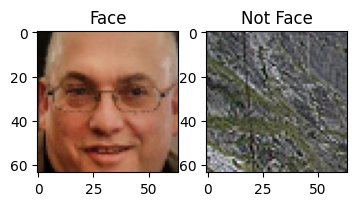

In [ ]:
face_images = images[np.where(labels == 1)[0]]
not_face_images = images[np.where(labels == 0)[0]]

idx_face = 25
idx_not_face = 16

plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(face_images[idx_face])
plt.title("Face")
plt.grid(False)

plt.subplot(1, 2, 2)
plt.imshow(not_face_images[idx_not_face])
plt.title("Not Face")
plt.grid(False)

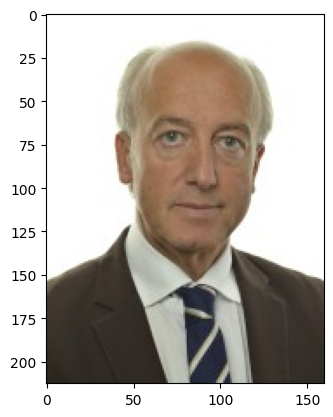

In [ ]:
ppb = PPBFaceEvaluator(skip=4)

gender = "male"  # ["male", "female"]
skin_color = "lighter"  # ["lighter", "darker"]

img = ppb.get_sample_faces_from_demographic(gender, skin_color)
plt.imshow(img)
plt.grid(False)

### Model CNN do rozpoznawiania twarzy

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, BatchNormalization, Dense, Flatten, Dropout


n_outputs = 1  # number of outputs (i.e., face or not face)
n_filters = 12  # base number of convolutional filters

"""Function to define a standard CNN model"""


def make_standard_classifier():
    x = Input(shape=(64, 64, 3))
    c1 = Conv2D(
        filters=1 * n_filters,
        kernel_size=[5, 5],
        strides=[2, 2],
        padding="same",
        activation="relu",
    )(x)
    c1 = BatchNormalization()(c1)
    c2 = Conv2D(
        filters=2 * n_filters,
        kernel_size=[5, 5],
        strides=[2, 2],
        padding="same",
        activation="relu",
    )(c1)
    c2 = BatchNormalization()(c2)
    c3 = Conv2D(
        filters=4 * n_filters,
        kernel_size=[3, 3],
        strides=[2, 2],
        padding="same",
        activation="relu",
    )(c2)
    c3 = BatchNormalization()(c3)
    c4 = Conv2D(
        filters=6 * n_filters,
        kernel_size=[3, 3],
        strides=[1, 1],
        padding="same",
        activation="relu",
    )(c3)
    c4 = BatchNormalization()(c4)
    rf = Flatten()(c4)
    d1 = Dense(32, activation="relu")(rf)
    d1 = Dropout(0.5)(d1)
    out = Dense(2, activation="softmax")(d1)
    return Model(inputs=x, outputs=out)


standard_classifier = make_standard_classifier()
standard_classifier.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 12)     │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 24)     │         7,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 48)       │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 72)       │        31,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 72)       │           288 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,906 (773.07 KB)

 Trainable params: 197,594 (771.85 KB)

 Non-trainable params: 312 (1.22 KB)

Trenowanie

In [ ]:
from keras.optimizers import Adam

batch_size = 64 * 50
num_epochs = 3
learning_rate = 1e-3

optimizer = Adam(learning_rate=learning_rate)  # define our optimizer
standard_classifier.compile(
    optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# The training loop!
for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    for idx in range(loader.get_train_size() // batch_size):
        # First grab a batch of training data and convert the input images to tensors
        x, y = loader.get_batch(batch_size)
        hist = standard_classifier.fit(x, y, batch_size=64, epochs=1)

Epoch:  0
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9216 - loss: 0.2126
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9775 - loss: 0.0674
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9794 - loss: 0.0638
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9872 - loss: 0.0446
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9878 - loss: 0.0486
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9866 - loss: 0.0506
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9919 - loss: 0.0372
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.0270
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9872 - loss: 0.0381
50/50 ━━━━━━━━━━━━━━━━━━━━ -0s -2878us/step - accuracy: 0.9894 - loss: 0.0350
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.0263
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9937 - loss: 0.0255
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9925 - loss: 0.0192
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

Ocena na danych uczących

In [ ]:
# Evaluate on a subset of CelebA+Imagenet
(batch_x, batch_y) = loader.get_batch(5000)
er = standard_classifier.evaluate(batch_x, batch_y)
print(
    "Standard CNN accuracy on (potentially biased) training set: {:.4f}".format(er[1])
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9986 - loss: 0.0070
Standard CNN accuracy on (potentially biased) training set: 0.9986


Ocena na danych testowych z rozbiciem na płeć i kolor skóry:

In [ ]:
ppb = PPBFaceEvaluator(skip=1)
# Evaluate on PPB dataset
standard_cnn_accuracy = []
for skin_color in ["lighter", "darker"]:
    for gender in ["male", "female"]:
        standard_cnn_accuracy.append(
            ppb.evaluate([standard_classifier], gender, skin_color)[0]
        )
        print()
        print("{} {}: {}".format(gender, skin_color, standard_cnn_accuracy[-1]))


male lighter: 0.9675569846767951

female lighter: 0.9694328652575542

male darker: 0.9729240369222245

female darker: 0.965360655585397


Text(0, 0.5, 'Accuracy')

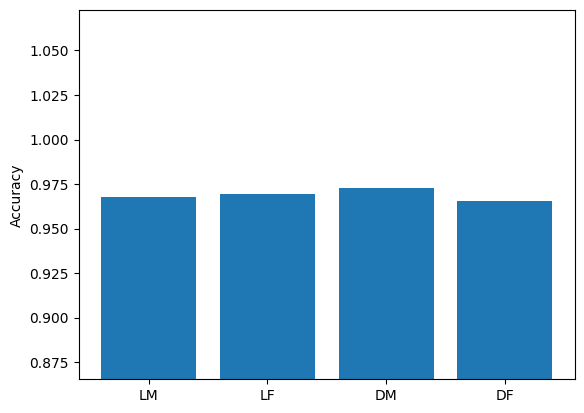

In [ ]:
plt.figure()
plt.bar(range(4), standard_cnn_accuracy)
plt.xticks(range(4), ("LM", "LF", "DM", "DF"))
plt.ylim(np.min(standard_cnn_accuracy) - 0.1, np.max(standard_cnn_accuracy) + 0.1)
plt.ylabel("Accuracy")

### Variational autoencoder (VAE) for learning latent structure
![enc_dec](http://torus.uck.pk.edu.pl/~amarsz/images/zmum/enc_dec.PNG)

Aby pozbyć się przeciążenia występującego w danych, storzony zostanie model AutoEncodera, który będzie miał za zadanie nauczyć się reprezentacji zdjęcia w postaci dwóch wektorów: wartości średniej i odchylenia standardowego. W taki sposób aby z wygenrowanego losowego wektora z rozkładu o tych parametrach móc odtworzyć wejściowe zdejęcie. Równiez na bazie tego losowego wektora dokonywane będzei rozpoznowanie twarzy.

W idealnym przypadku, który chcielibyśmy osiągnąć, autoenkoder powinnien nauczyć się losowo modyfikować wejściowe zdjęcie ze względu na płeć i kolor skóry.

### Reparametryzacja
$$ z = \mathbb{\mu} + e^{\left(\frac{1}{2} \cdot \log{\Sigma}\right)}\circ \epsilon $$

gdzie  $\mu$ wartość średnia, $\Sigma$ macierz kowariancji oraz $\epsilon \sim \mathcal{N}(0,(I))$.

In [ ]:
"""Reparameterization trick by sampling from an isotropic unit Gaussian.
# Arguments
    args (tensor): mean and standard deviation of latent distribution (Q(z|X))
# Returns
    z (tensor): sampled latent vector
"""


def sampling(args):
    z_mean, z_sigma = args[0], args[1]
    batch = keras.backend.shape(z_mean)[0]
    dim = keras.backend.int_shape(z_mean)[1]
    # by default, random_normal has mean=0 and std=1.0
    epsilon = keras.backend.random_normal((batch, dim))
    return z_mean + z_sigma * epsilon


def sampling_output_shape(args):
    z_mean, z_sigma = args
    return z_mean.shape

### Encoder

In [ ]:
from keras.models import Sequential, Model
from keras.layers import (
    Conv2D,
    BatchNormalization,
    Dense,
    Flatten,
    Dropout,
    Input,
    Lambda,
    Conv2DTranspose,
    Reshape,
    Concatenate,
)
from keras.optimizers import Adam

latent_dim = 100

n_outputs = 1  # number of outputs (i.e., face or not face)
n_filters = 12  # base number of convolutional filters

inputs = Input(shape=(64, 64, 3))
hidden = Conv2D(
    filters=1 * n_filters,
    kernel_size=[5, 5],
    strides=[2, 2],
    padding="same",
    activation="relu",
)(inputs)
hidden = BatchNormalization()(hidden)
hidden = Conv2D(
    filters=2 * n_filters,
    kernel_size=[5, 5],
    strides=[2, 2],
    padding="same",
    activation="relu",
)(hidden)
hidden = BatchNormalization()(hidden)
hidden = Conv2D(
    filters=4 * n_filters,
    kernel_size=[3, 3],
    strides=[2, 2],
    padding="same",
    activation="relu",
)(hidden)
hidden = BatchNormalization()(hidden)
hidden = Conv2D(
    filters=6 * n_filters,
    kernel_size=[3, 3],
    strides=[1, 1],
    padding="same",
    activation="relu",
)(hidden)
hidden = BatchNormalization()(hidden)
hidden = Flatten(name="flatten")(hidden)
# hidden = Dense(128, activation='relu')(hidden)

"""Encoder outputs:
    y_logit: supervised class prediction
    z_mean: means in the latent space
    z_sigma: standard deviations in the latent space"""
y_logit = Dense(2, activation="softmax", name="y_logit")(hidden)
z_mean = Dense(latent_dim, activation="linear", name="z_mean")(hidden)
z_sigma = Dense(latent_dim, activation="softplus", name="z_sigma")(hidden)
parm = Concatenate(name="parm")([z_mean, z_sigma])

# use reparameterization trick to sample from the latent space
z = Lambda(sampling, output_shape=z_mean.shape[1:])([z_mean, z_sigma])

# define the outputs that the encoder model should return
outputs = [y_logit, parm, z]
# finalize the encoder model
encoder = Model(inputs=inputs, outputs=outputs, name="encoder")

### Decoder

In [ ]:
# get the shape of the final convolutional output (right before the flatten)
flatten_layer_idx = encoder.layers.index(encoder.get_layer("flatten"))
pre_flatten_shape = (
    encoder.layers[flatten_layer_idx - 2]._inbound_nodes[0].outputs[0].shape[1:]
)
pre_flatten_shape

(8, 8, 72)

In [ ]:
latent_inputs = Input(shape=(latent_dim,))

hidden = Dense(int(np.prod(np.array(pre_flatten_shape))), activation="relu")(
    latent_inputs
)
hidden = Reshape(pre_flatten_shape)(hidden)

# series of deconvolutional layers with batch normalization
hidden = Conv2DTranspose(
    filters=4 * n_filters,
    kernel_size=[3, 3],
    strides=[1, 1],
    padding="same",
    activation="relu",
)(hidden)
hidden = BatchNormalization()(hidden)
hidden = Conv2DTranspose(
    filters=2 * n_filters,
    kernel_size=[3, 3],
    strides=[2, 2],
    padding="same",
    activation="relu",
)(hidden)
hidden = BatchNormalization()(hidden)
hidden = Conv2DTranspose(
    filters=1 * n_filters,
    kernel_size=[5, 5],
    strides=[2, 2],
    padding="same",
    activation="relu",
)(hidden)
hidden = BatchNormalization()(hidden)
x_hat = Conv2DTranspose(
    filters=3,
    kernel_size=[5, 5],
    strides=[2, 2],
    padding="same",
    activation="relu",
    name="x_hat",
)(hidden)

# instantiate decoder model
decoder = Model(inputs=latent_inputs, outputs=x_hat, name="decoder")

### Cały model

In [46]:
reconstructed_inputs = decoder(z)
vae = Model(inputs, [reconstructed_inputs, parm, y_logit])
vae.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │        912 │ input_layer_6[0]… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         48 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │      7,224 │ batch_normalizat… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         96 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8, 48)  │     10,416 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 48)  │        192 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 8, 8, 72)  │     31,176 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 72)  │        288 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4608)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 100)       │    460,900 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sigma (Dense)     │ (None, 100)       │    460,900 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 100)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_sigma[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 64, 64, 3) │    515,403 │ lambda_1[0][0]    │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ parm (Concatenate)  │ (None, 200)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_sigma[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y_logit (Dense)     │ (None, 2)         │      9,218 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,496,773 (5.71 MB)

 Trainable params: 1,496,293 (5.71 MB)

 Non-trainable params: 480 (1.88 KB)

### Trenowanie

In [ ]:
from keras.optimizers import Adam

batch_size = 64 * 50
num_epochs = 3
learning_rate = 1e-3

optimizer = Adam(learning_rate=learning_rate)


def latent_loss(y_true, y_pred):
    face_indicator = tf.cast(tf.equal(y_true, 1), tf.float32)
    mu = y_pred[:, :latent_dim]
    sigma = y_pred[:, latent_dim:]
    return tf.reduce_mean(
        face_indicator
        * (
            0.5
            * tf.reduce_sum(sigma + tf.square(mu) - 1.0 - tf.math.log(sigma), axis=1)
        ),
        axis=-1,
    )


losses = {
    "y_logit": "sparse_categorical_crossentropy",
    "decoder": "mse",
    "parm": latent_loss,
}
lossWeights = {"y_logit": 0.5, "decoder": 0.4995, "parm": 0.0005}
vae.compile(
    optimizer=optimizer,
    loss=losses,
    loss_weights=lossWeights,
    metrics={"y_logit": "accuracy"},
)

# The training loop!
for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    for idx in range(loader.get_train_size() // batch_size):
        # First grab a batch of training data and convert the input images to tensors
        prob = None  # get_training_sample_probabilities(images, dbvae, bins=10, smoothing_fac=0.001)
        x, y = loader.get_batch(batch_size, p_pos=prob)
        y_train = {"y_logit": y, "decoder": x, "parm": y}
        hist = vae.fit(x, y_train, batch_size=16, epochs=1)

Epoch:  0
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - decoder_loss: 0.0891 - loss: 0.1337 - parm_loss: 47.5978 - y_logit_accuracy: 0.9638 - y_logit_loss: 0.1309
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - decoder_loss: 0.0528 - loss: 0.0901 - parm_loss: 52.7812 - y_logit_accuracy: 0.9769 - y_logit_loss: 0.0747
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - decoder_loss: 0.0432 - loss: 0.0840 - parm_loss: 47.5573 - y_logit_accuracy: 0.9816 - y_logit_loss: 0.0774
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - decoder_loss: 0.0389 - loss: 0.0745 - parm_loss: 24.9405 - y_logit_accuracy: 0.9819 - y_logit_loss: 0.0852
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - decoder_loss: 0.0370 - loss: 0.0577 - parm_loss: 18.0048 - y_logit_accuracy: 0.9847 - y_logit_loss: 0.0605
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - decoder_loss: 0.0356 - loss: 0.0520 - parm_loss: 15.5403 - y_logit_accuracy: 0.9875 - y_logit_loss: 0.0529 
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - decoder_loss: 0.0340 - loss: 0.0428 - parm_los

Ocena na zbiorze uczącym

In [ ]:
# Evaluate on a subset of CelebA+Imagenet
(batch_x, batch_y) = loader.get_batch(5000)
y_pred = vae.predict(batch_x)[2]
y_pred = np.argmax(y_pred, axis=1)
acc = np.mean((batch_y.flatten() == y_pred).astype(int))

print("Standard CNN accuracy on training set: {:.4f}".format(acc))

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Standard CNN accuracy on training set: 0.9978


Ocena zbioru testowego

In [ ]:
ppb = PPBFaceEvaluator(skip=1)
# Evaluate on PPB dataset
standard_cnn_accuracy = []
for skin_color in ["lighter", "darker"]:
    for gender in ["male", "female"]:
        standard_cnn_accuracy.append(
            ppb.evaluate([vae], gender, skin_color, output_idx=2)[0]
        )
        print()
        print("{} {}: {}".format(gender, skin_color, standard_cnn_accuracy[-1]))


male lighter: 0.9846039448624763

female lighter: 0.9839142211094386


2026-04-15 10:38:13.237952: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion_1', 12 bytes spill stores, 12 bytes spill loads

2026-04-15 10:38:20.816864: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion_1', 12 bytes spill stores, 12 bytes spill loads

2026-04-15 10:38:26.408984: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_258', 4 bytes spill stores, 4 bytes spill loads




male darker: 0.9845173491364142

female darker: 0.9800619203621957


Text(0, 0.5, 'Accuracy')

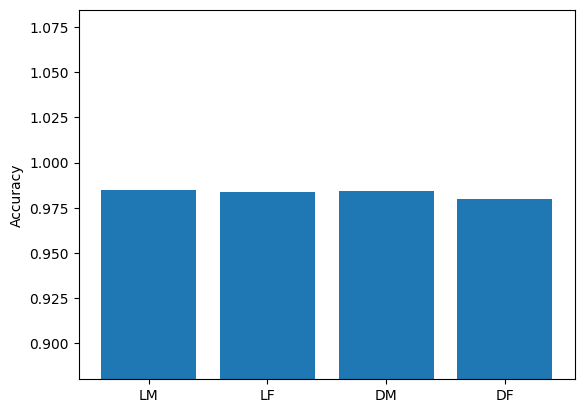

In [ ]:
plt.figure()
plt.bar(range(4), standard_cnn_accuracy)
plt.xticks(range(4), ("LM", "LF", "DM", "DF"))
plt.ylim(np.min(standard_cnn_accuracy) - 0.1, np.max(standard_cnn_accuracy) + 0.1)
plt.ylabel("Accuracy")

### Analiza przestrzeni ukrytej
Przykładowe zdjęcie twarzy

In [ ]:
nr = 4  # numer zdjecia z twarzą
face_images = images[np.where(labels == 1)[0]]
img = face_images[nr : nr + 1]

Predykcja dla wybranego zdjęcia

In [ ]:
pred = vae.predict(img)
pred[0].shape, pred[2].shape, pred[
    1
].shape  # odtworzone zdjęcie, klasa, parametry mu i sigma

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


((1, 64, 64, 3), (1, 2), (1, 200))

Na podstawie nauczonych `mu` i `sigma` wygenerujemy kilka wektorów `z` z których odtworzymy zdjęcie

In [ ]:
z_mean, z_sigma = pred[1][:, :latent_dim], pred[1][:, latent_dim:]
epsilon = np.random.randn(15, latent_dim)  # będzie 15 różnych z
z = z_mean + z_sigma * epsilon
x_hat = decoder.predict(z)
x_mean = decoder.predict(z_mean)
x_hat.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


(15, 64, 64, 3)

Od lewej:
- oryginalne zdjęcie
- odtworzone zdjęcie ze wektora średniego
- losowe zdjęcia

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1066386].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1191102].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0948824].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1382004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1128045].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1234599].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1309807].
Clipping input data to the valid r

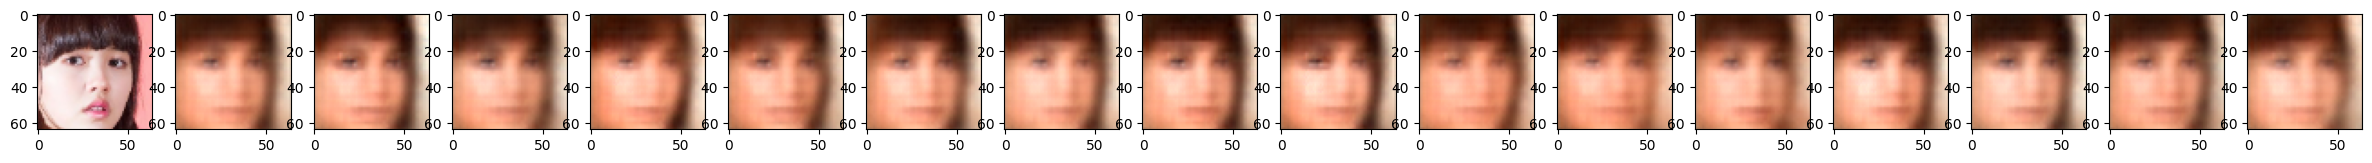

In [ ]:
plt.figure(figsize=(30, 10))
plt.subplot(1, x_hat.shape[0] + 2, 1)
plt.imshow(img[0])
plt.subplot(1, x_hat.shape[0] + 2, 2)
plt.imshow(x_mean[0])
for i in range(2, x_hat.shape[0] + 2):
    plt.subplot(1, x_hat.shape[0] + 2, i + 1)
    plt.imshow(x_hat[i - 2])

Trochę mniej losowości, epsilon posortowane, od -2.2 do 2.2, każda składowa wektora zmieniana o tą samo wartość.

In [ ]:
z_mean, z_sigma = pred[1][:, :latent_dim], pred[1][:, latent_dim:]
epsilon = np.linspace(-2.2, 2.2, 15)
epsilon = np.sort(epsilon)
epsilon = np.tile(epsilon.reshape((15, 1)), (1, latent_dim))
z = z_mean + z_sigma * epsilon
x_hat = decoder.predict(z)
x_mean = decoder.predict(z_mean)
x_hat.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


(15, 64, 64, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1066386].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0051339865..1.1727107].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1487242].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1276242].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1189368].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.112591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1089654].
Clipping input data to the

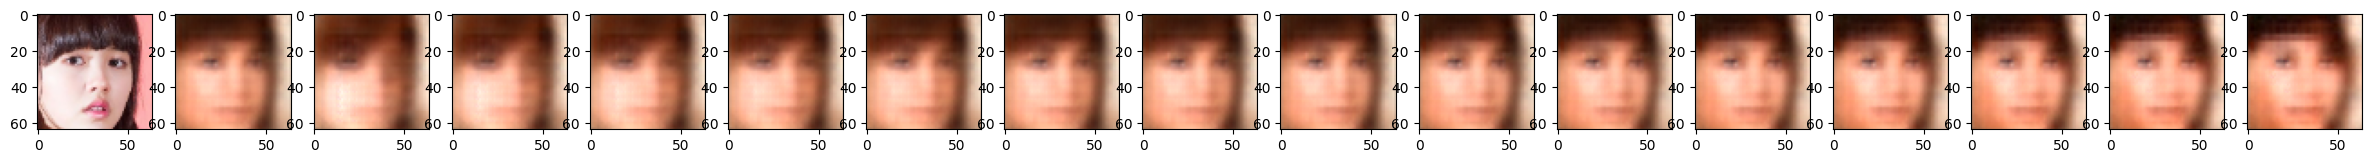

In [ ]:
plt.figure(figsize=(30, 10))
plt.subplot(1, x_hat.shape[0] + 2, 1)
plt.imshow(img[0])
plt.subplot(1, x_hat.shape[0] + 2, 2)
plt.imshow(x_mean[0])
for i in range(2, x_hat.shape[0] + 2):
    plt.subplot(1, x_hat.shape[0] + 2, i + 1)
    plt.imshow(x_hat[i - 2])

### Ćwiczenia do wykonania
- Stwórz model VAE dla danych MNIST, spróbuj za pomoca wytrenowanego modelu zidentyfikować anomalie w zbiorze danych (dane odstające).
- Denoising Autoencoder. Wyternuj model autoenkodera na zaszumionych danych: Wejście = zaszumiony obraz, Wyjście = czysty obraz. Sprawdź na zbiorze testowym jak model odszumia obrazy.
- Wyodrębnik dwa wektory dla dwóch różnych cyfr (np. wektor $z_1$ dla cyfry '2' i wektor $z_2$ dla cyfry '8'). Następnie wygeneruj 10 wektorów pośrednich (liniowa interpolacja wektorów) i zdekodują je.

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 218.7836 - val_loss: 195.2771
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 192.3960 - val_loss: 188.9995
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 187.7125 - val_loss: 185.2986
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 185.0728 - val_loss: 183.2407
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 183.3116 - val_loss: 181.3270
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 169.9253 - val_loss: 165.2854
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 163.2959 - val_loss: 161.4559
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 161.1400 - val_loss: 159.9302
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 159.8668 - val_loss: 158.8530
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 158.8525 - val_loss: 158.3429
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 158.0243 - val_loss: 157.8871
Epoch 1

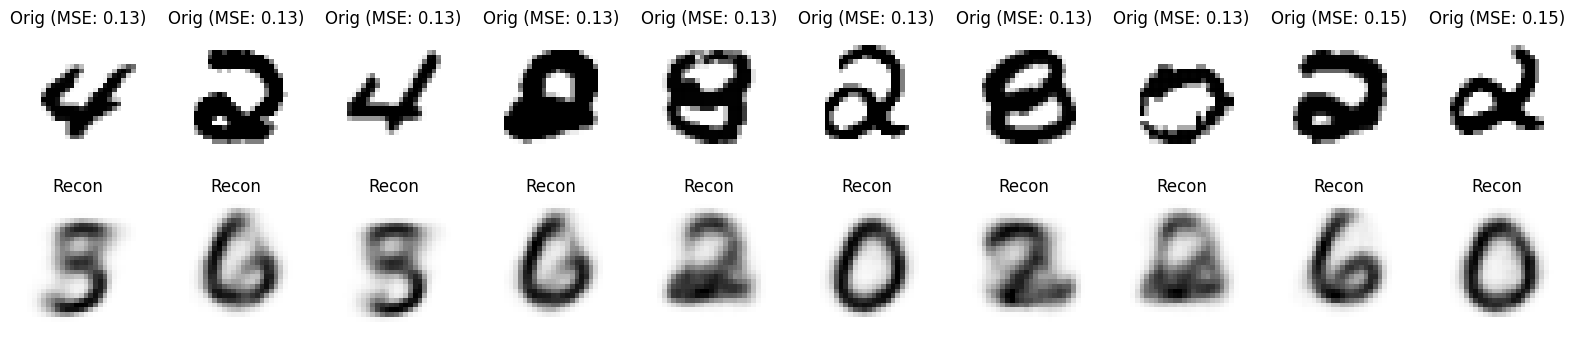

In [ ]:
latent_dim_mnist = 2

# Encoder
mnist_inputs = Input(shape=(28, 28, 1))
x = Conv2D(32, 3, strides=2, padding="same", activation="relu")(mnist_inputs)
x = Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = Flatten()(x)
x = Dense(16, activation="relu")(x)

z_mean_mnist = Dense(latent_dim_mnist, name="z_mean_mnist")(x)
z_log_var_mnist = Dense(latent_dim_mnist, name="z_log_var_mnist")(x)


def sampling_mnist(args):
    z_m, z_l_v = args
    batch = tf.shape(z_m)[0]
    dim = tf.shape(z_m)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return z_m + tf.exp(0.5 * z_l_v) * epsilon


z_mnist = Lambda(sampling_mnist, output_shape=(latent_dim_mnist,), name="z_mnist")(
    [z_mean_mnist, z_log_var_mnist]
)
encoder_mnist = Model(
    mnist_inputs, [z_mean_mnist, z_log_var_mnist, z_mnist], name="encoder_mnist"
)

# Decoder
latent_inputs_mnist = Input(shape=(latent_dim_mnist,), name="z_sampling_mnist")
x = Dense(7 * 7 * 64, activation="relu")(latent_inputs_mnist)
x = Reshape((7, 7, 64))(x)
x = Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x = Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
mnist_outputs = Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)

decoder_mnist = Model(latent_inputs_mnist, mnist_outputs, name="decoder_mnist")

# VAE
outputs_mnist = decoder_mnist(encoder_mnist(mnist_inputs)[2])


class VAELossLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        img_in, img_out, z_mean, z_log_var = inputs
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(img_in, img_out), axis=(1, 2)
            )
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        self.add_loss(reconstruction_loss + kl_loss)
        return img_out


outputs_mnist = VAELossLayer()(
    [mnist_inputs, outputs_mnist, z_mean_mnist, z_log_var_mnist]
)
vae_mnist = Model(mnist_inputs, outputs_mnist, name="vae_mnist")

vae_mnist.compile(optimizer="adam")
vae_mnist.fit(
    train_images, epochs=30, batch_size=128, validation_data=(test_images, None)
)

# Anomaly detection (Outliers based on reconstruction MSE)
reconstructions = vae_mnist.predict(test_images)
mse = np.mean(np.square(test_images - reconstructions), axis=(1, 2, 3))
anomaly_indices = np.argsort(mse)[-10:]

plt.figure(figsize=(20, 4))
for i, idx in enumerate(anomaly_indices):
    plt.subplot(2, 10, i + 1)
    plt.imshow(np.squeeze(test_images[idx]), cmap="binary")
    plt.title(f"Orig (MSE: {mse[idx]:.2f})")
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(np.squeeze(reconstructions[idx]), cmap="binary")
    plt.title("Recon")
    plt.axis("off")

Epoch 1/10
416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3705

2026-04-15 10:47:03.730647: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[112,16,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[112,1,29,29]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-04-15 10:47:03.732783: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 50.39831884s
Trying algorithm eng0{} for conv (f32[112,16,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[112,1,29,29]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward",

422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2067 - val_loss: 0.0923
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0879 - val_loss: 0.0866
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0848 - val_loss: 0.0845
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0836 - val_loss: 0.0836
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0828 - val_loss: 0.0830
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0823 - val_loss: 0.0826
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0819 - val_loss: 0.0823
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0817 - val_loss: 0.0819
Epoch 9/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0813 - val_loss: 0.0817
Epoch 10/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0810 - val_loss: 0.0814
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


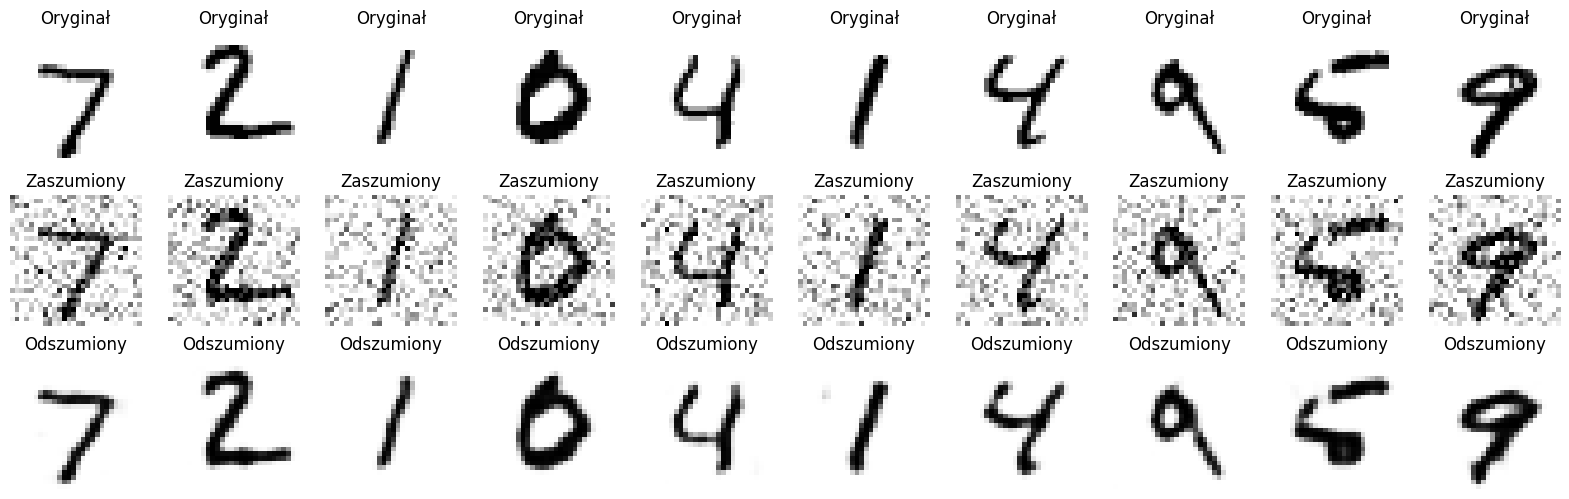

In [ ]:
# Dodawanie szumu do obrazów
noise_factor = 0.3
train_images_noisy = train_images + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=train_images.shape
)
test_images_noisy = test_images + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=test_images.shape
)

train_images_noisy = np.clip(train_images_noisy, 0.0, 1.0)
test_images_noisy = np.clip(test_images_noisy, 0.0, 1.0)

# Budowa modelu Denoising Autoencoder
denoising_inputs = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(16, (3, 3), activation="relu", padding="same", strides=2)(denoising_inputs)
x = Conv2D(8, (3, 3), activation="relu", padding="same", strides=2)(x)

# Decoder
x = Conv2DTranspose(8, kernel_size=3, strides=2, activation="relu", padding="same")(x)
x = Conv2DTranspose(16, kernel_size=3, strides=2, activation="relu", padding="same")(x)
denoising_outputs = Conv2D(1, kernel_size=(3, 3), activation="sigmoid", padding="same")(
    x
)

denoising_ae = Model(denoising_inputs, denoising_outputs, name="denoising_ae")
denoising_ae.compile(optimizer="adam", loss="binary_crossentropy")

# Trenowanie modelu
denoising_ae.fit(
    train_images_noisy, train_images, epochs=10, batch_size=128, validation_split=0.1
)

# Przewidywanie na zbiorze testowym
denoised_images = denoising_ae.predict(test_images_noisy)

# Wizualizacja wyników
plt.figure(figsize=(20, 6))
for i in range(10):
    # Oryginalny obraz
    plt.subplot(3, 10, i + 1)
    plt.imshow(np.squeeze(test_images[i]), cmap="binary")
    plt.title("Oryginał")
    plt.axis("off")

    # Zaszumiony obraz
    plt.subplot(3, 10, i + 11)
    plt.imshow(np.squeeze(test_images_noisy[i]), cmap="binary")
    plt.title("Zaszumiony")
    plt.axis("off")

    # Odszumiony obraz
    plt.subplot(3, 10, i + 21)
    plt.imshow(np.squeeze(denoised_images[i]), cmap="binary")
    plt.title("Odszumiony")
    plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step


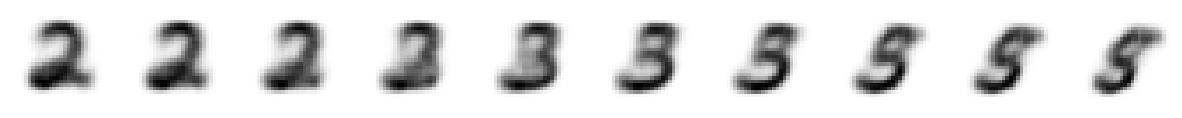

In [ ]:
# Znajdź indeksy dla cyfr 2 i 8
idx_2 = np.where(test_labels == 2)[0][0]
idx_8 = np.where(test_labels == 8)[0][0]

# Wyodrębnij obrazy
img_2 = test_images[idx_2]
img_8 = test_images[idx_8]

# Przewiduj wektory ukryte (z) dla obu obrazów
_, _, z1 = encoder_mnist.predict(np.expand_dims(img_2, axis=0))
_, _, z2 = encoder_mnist.predict(np.expand_dims(img_8, axis=0))

# Generuj 10 wektorów pośrednich
alphas = np.linspace(0, 1, 10)
interpolated_z = np.array([(1 - alpha) * z1 + alpha * z2 for alpha in alphas])
interpolated_z = np.squeeze(interpolated_z)

# Dekoduj wektory pośrednie
decoded_images = decoder_mnist.predict(interpolated_z)

# Wizualizacja
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(np.squeeze(decoded_images[i]), cmap="binary")
    plt.axis("off")
plt.show()